## **1**.Tokenization



# **Track** 1.1 : Use split()

Use the standard `split()` by Python.

In [19]:
# Sample sentence
sentence = "Tokenization is the process of breaking a sentence into words."

# Using Python's split() function to tokenize the sentence
tokens = sentence.split()

# Output the tokens
print("Tokens:", tokens)


Tokens: ['Tokenization', 'is', 'the', 'process', 'of', 'breaking', 'a', 'sentence', 'into', 'words.']


# **Track** 1.2 : Use *NLTK*

NLTK tokenizer: https://www.nltk.org/api/nltk.tokenize.html

In [20]:
#pip install nltk

In [21]:
import nltk
from nltk.tokenize import word_tokenize

# Download NLTK data files
nltk.download('punkt')

# Sample sentence
sentence = "Tokenization is the process of breaking a sentence into words."

# Using NLTK's word_tokenize() function to tokenize the sentence
tokens = word_tokenize(sentence)

# Output the tokens
print("Tokens:", tokens)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Tokens: ['Tokenization', 'is', 'the', 'process', 'of', 'breaking', 'a', 'sentence', 'into', 'words', '.']


Punkt is a pre-trained tokenizer model in NLTK that can be used for tokenizing text into words or sentences.
It is capable of recognizing sentence boundaries (i.e., determining where one sentence ends and the next begins) and can handle various punctuation marks and abbreviations.

# **Track** .2 : Use Byte-Pair Encoding (BPE)**

Byte-Pair Encoding (BPE): https://huggingface.co/transformers/tokenizer_summary.html

Note: You may need to install Huggingface's transformers so please refer to its website for installation instructions.


In [22]:
pip install tokenizers

In [23]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders

# Create a tokenizer using the BPE model
tokenizer = Tokenizer(models.BPE())

# Set up pre-tokenizer (optional, but helps in initial processing)
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel()

# Set up the decoder
tokenizer.decoder = decoders.ByteLevel()

# Prepare some sample text
texts = [
    "Tokenization is the process of breaking a sentence into words.",
    "This is an example to demonstrate Byte Pair Encoding."
]

# Train the tokenizer on the provided texts
trainer = trainers.BpeTrainer()
tokenizer.train_from_iterator(texts, trainer=trainer)

# Example sentence to tokenize
sentence = "Tokenization is the process of breaking a sentence into words."

# Use the tokenizer to encode the sentence
encoded = tokenizer.encode(sentence)

# Output the tokens
print("Tokens:", encoded.tokens)

Tokens: ['ĠTokenization', 'Ġis', 'Ġthe', 'Ġprocess', 'Ġof', 'Ġbreaking', 'Ġa', 'Ġsentence', 'Ġinto', 'Ġwords', '.']


In [24]:
# Removing the 'Ġ' character from tokens
cleaned_tokens = [token.replace('Ġ', '') for token in encoded.tokens]
print("Cleaned Tokens:", cleaned_tokens)

Cleaned Tokens: ['Tokenization', 'is', 'the', 'process', 'of', 'breaking', 'a', 'sentence', 'into', 'words', '.']


## Part 2: Build Word Representations

# **2.1. Use N-gram Language Modeling**

In [25]:
from nltk import ngrams
import nltk

# Download NLTK data files (if not already done)
nltk.download('punkt')

# Sample sentence
sentence = "Tokenization is the process of breaking a sentence into words."

# Tokenize the sentence into words
tokens = nltk.word_tokenize(sentence)

# Function to generate N-grams
def generate_ngrams(tokens, n):
    return list(ngrams(tokens, n))

# Set the value of N (e.g., 2 for bigrams, 3 for trigrams)
N = 2

# Generate N-grams
ngrams_output = generate_ngrams(tokens, N)

# Output the N-grams
print(f"{N}-grams:", ngrams_output)


2-grams: [('Tokenization', 'is'), ('is', 'the'), ('the', 'process'), ('process', 'of'), ('of', 'breaking'), ('breaking', 'a'), ('a', 'sentence'), ('sentence', 'into'), ('into', 'words'), ('words', '.')]


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [26]:
from nltk import ngrams
import nltk

# Download NLTK data files (if not already done)
nltk.download('punkt')

# Sample sentence
sentence = "Tokenization is the process of breaking a sentence into words."

# Tokenize the sentence into words
tokens = nltk.word_tokenize(sentence)

# Function to generate N-grams
def generate_ngrams(tokens, n):
    return list(ngrams(tokens, n))

# Set the value of N (e.g., 2 for bigrams, 3 for trigrams)
N = 3

# Generate N-grams
ngrams_output = generate_ngrams(tokens, N)

# Output the N-grams
print(f"{N}-grams:", ngrams_output)


3-grams: [('Tokenization', 'is', 'the'), ('is', 'the', 'process'), ('the', 'process', 'of'), ('process', 'of', 'breaking'), ('of', 'breaking', 'a'), ('breaking', 'a', 'sentence'), ('a', 'sentence', 'into'), ('sentence', 'into', 'words'), ('into', 'words', '.')]


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **2.2. Use Skip-gram with Negative Sampling**



In [27]:
sentences = [
    "Tokenization is the process of converting a sentence into tokens.",
    "Splitting is the process of breaking a sentence into words.",
    "Tokenization and splitting are essential steps in natural language processing.",
    "Splitting sentences into words is often part of tokenization in text processing.",
    "The task of tokenization involves splitting text into individual words or tokens.",
    "Tokenization helps split and analyze a sentence by breaking it down into words.",
    "Tokenization is a key preprocessing step in NLP models.",
    "Effective tokenization leads to better performance in text processing tasks.",
    "Tokenization often involves splitting sentences into words and removing stopwords.",
    "When we tokenize text, we split it into tokens such as words or phrases.",
    "During tokenization, we split a sentence into manageable pieces for analysis.",
    "Tokenization plays a critical role in transforming text into a format that machines can process.",
    "The tokenization process can be customized by splitting text based on various rules."
    ]

In [28]:
"""sentences = [
    "Stock prices fluctuate based on market conditions and investor sentiment.",
    "Portfolio diversification helps reduce financial risk.",
    "Asset allocation is an essential part of building a balanced investment portfolio.",
    "Market analysis involves evaluating financial trends and indicators to make informed decisions.",
    "The task of financial modeling involves predicting future stock performance based on historical data.",
    "Risk management helps mitigate losses in volatile financial markets.",
    "Investors often diversify portfolios to minimize potential losses.",
    "Effective portfolio management leads to better long-term financial returns.",
    "Market volatility can significantly impact stock prices and investor behavior.",
    "When we analyze financial data, we look for patterns that can predict market movements.",
    "During financial forecasting, we use historical data to predict future performance.",
    "Financial modeling plays a critical role in evaluating investment opportunities.",
    "The process of portfolio optimization can be customized by balancing risk and return based on various factors."
]"""

'sentences = [\n    "Stock prices fluctuate based on market conditions and investor sentiment.",\n    "Portfolio diversification helps reduce financial risk.",\n    "Asset allocation is an essential part of building a balanced investment portfolio.",\n    "Market analysis involves evaluating financial trends and indicators to make informed decisions.",\n    "The task of financial modeling involves predicting future stock performance based on historical data.",\n    "Risk management helps mitigate losses in volatile financial markets.",\n    "Investors often diversify portfolios to minimize potential losses.",\n    "Effective portfolio management leads to better long-term financial returns.",\n    "Market volatility can significantly impact stock prices and investor behavior.",\n    "When we analyze financial data, we look for patterns that can predict market movements.",\n    "During financial forecasting, we use historical data to predict future performance.",\n    "Financial modeling

**Word2Vec modeli Skip-gram yöntemi ve Negative Sampling (Negatif Örnekleme) kullanılarak eğitiliyor.**

Word2Vec: Gensim kütüphanesi tarafından sağlanan Word2Vec modeli, kelimeleri sayısal vektörler (embedding) şeklinde temsil etmeye yarayan bir modeldir.

tokenized_sentences: Bu, eğitilecek veri setidir. Her cümle, kelimelere bölünmüş ve küçük harflere dönüştürülmüş durumda.

vector_size=100: Bu parametre, her kelimenin vektör uzayındaki boyutunu belirler. Burada, her kelime 100 boyutlu bir vektör ile temsil edilir.

window=5: Bu parametre, her hedef kelimenin etrafındaki kaç kelimenin dikkate alınacağını belirtir. Örneğin, bir kelimenin sağında ve solunda 5'er kelime dikkate alınır.

min_count=1: Bu parametre, eğitime dahil edilecek kelimelerin minimum görülme sıklığını belirtir. min_count=1 demek, bir kez bile geçen kelimelerin modele dahil edilmesini sağlar.

sg=1: Bu parametre, kullanılacak modelin türünü belirtir. sg=1 değeri, Skip-gram yöntemini kullanacağımızı gösterir. Eğer sg=0 olsaydı, Continuous Bag of Words (CBOW) yöntemi kullanılacaktı.

negative=5: Negative Sampling parametresidir. Kelime çiftlerinin pozitif örneklerini öğrenirken, 5 adet negatif örnek (yanlış kelime çiftleri) kullanılarak modelin daha verimli öğrenmesi sağlanır. Negative Sampling, büyük veri setlerinde hesaplama maliyetini düşürmek için kullanılır.

In [29]:
# Tokenize each sentence into words and convert to lowercase
tokenized_sentences = [sentence.lower().split() for sentence in sentences]

# Train Word2Vec model using Skip-gram with Negative Sampling
model = Word2Vec(tokenized_sentences, vector_size=100, window=5, min_count=1, sg=1, negative=5)

# Check if 'tokenization' is in the vocabulary
if 'tokenization' in model.wv.key_to_index:
    print("'tokenization' found in vocabulary!")
    # Find words similar to 'tokenization'
    similar_words = model.wv.most_similar('tokenization', topn=10)
    for word, score in similar_words:
        print(f"{word}: {score}")

'tokenization' found in vocabulary!
tokenize: 0.2936219573020935
by: 0.2238696664571762
the: 0.21520937979221344
better: 0.20373107492923737
be: 0.1987934112548828
customized: 0.17865318059921265
pieces: 0.17105607688426971
converting: 0.15244518220424652
are: 0.14701300859451294
transforming: 0.14541222155094147


## **Part 3: Explore the Word Representations**

Track 3.1: Visualise the word representations by t-SNE.
t-SNE is an algorithm to reduce dimentionality and commonly used to visualise high-dimension vectors. Use t-SNE to visualise the word representations.

More about t-SNE: https://lvdmaaten.github.io/tsne/

In [30]:
sentences = [
    "Tokenization is the process of converting a sentence into tokens.",
    "Splitting is the process of breaking a sentence into words.",
    "Tokenization and splitting are essential steps in natural language processing.",
    "Splitting sentences into words is often part of tokenization in text processing.",
    "The task of tokenization involves splitting text into individual words or tokens.",
    "Tokenization helps split and analyze a sentence by breaking it down into words.",
    "Tokenization is a key preprocessing step in NLP models.",
    "Effective tokenization leads to better performance in text processing tasks.",
    "Tokenization often involves splitting sentences into words and removing stopwords.",
    "When we tokenize text, we split it into tokens such as words or phrases.",
    "During tokenization, we split a sentence into manageable pieces for analysis.",
    "Tokenization plays a critical role in transforming text into a format that machines can process.",
    "The tokenization process can be customized by splitting text based on various rules."
    ]

In [31]:
!pip install gensim
from gensim.models import Word2Vec
import numpy as np
from sklearn.manifold import TSNE # Import TSNE from sklearn.manifold
import matplotlib.pyplot as plt # Import matplotlib for plotting

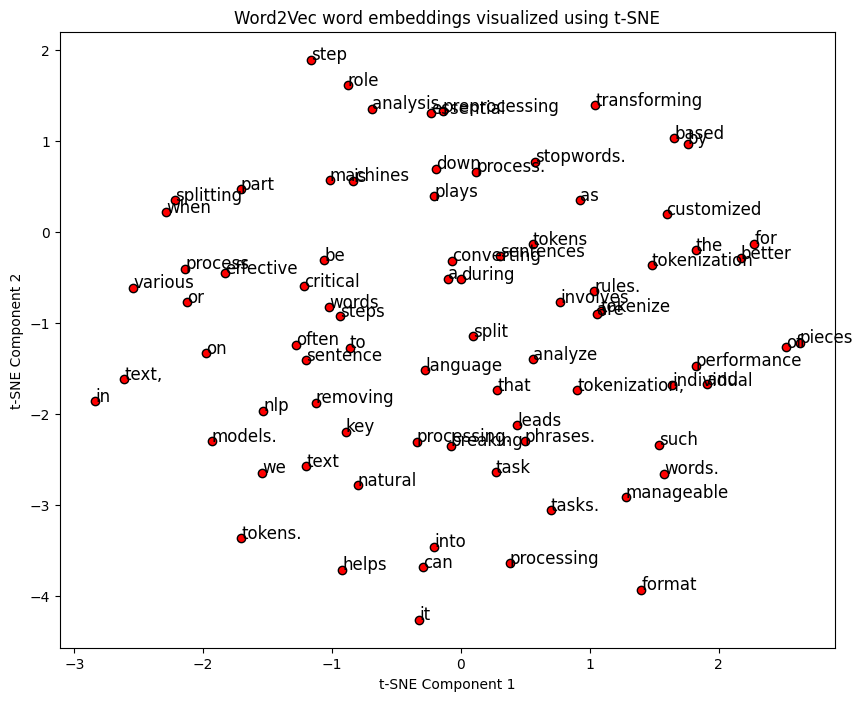

In [32]:
# Tokenize each sentence into words and convert to lowercase
tokenized_sentences = [sentence.lower().split() for sentence in sentences]

# Train Word2Vec model using Skip-gram with Negative Sampling
model = Word2Vec(tokenized_sentences, vector_size=100, window=5, min_count=1, sg=1, negative=5)

# Extract word vectors and corresponding words
words = list(set(model.wv.key_to_index))  # Ensure each word appears only once (no repetition)
word_vectors = np.array([model.wv[word] for word in words])

# Use t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=0)
word_vectors_2d = tsne.fit_transform(word_vectors)

# Plot the words in 2D space
plt.figure(figsize=(10, 8))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], edgecolors='k', c='r')

# Annotate each point with the word it represents
for i, word in enumerate(words):
    plt.text(word_vectors_2d[i, 0], word_vectors_2d[i, 1], word, fontsize=12)

plt.title("Word2Vec word embeddings visualized using t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

Track 3.3: Co-occurrence

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


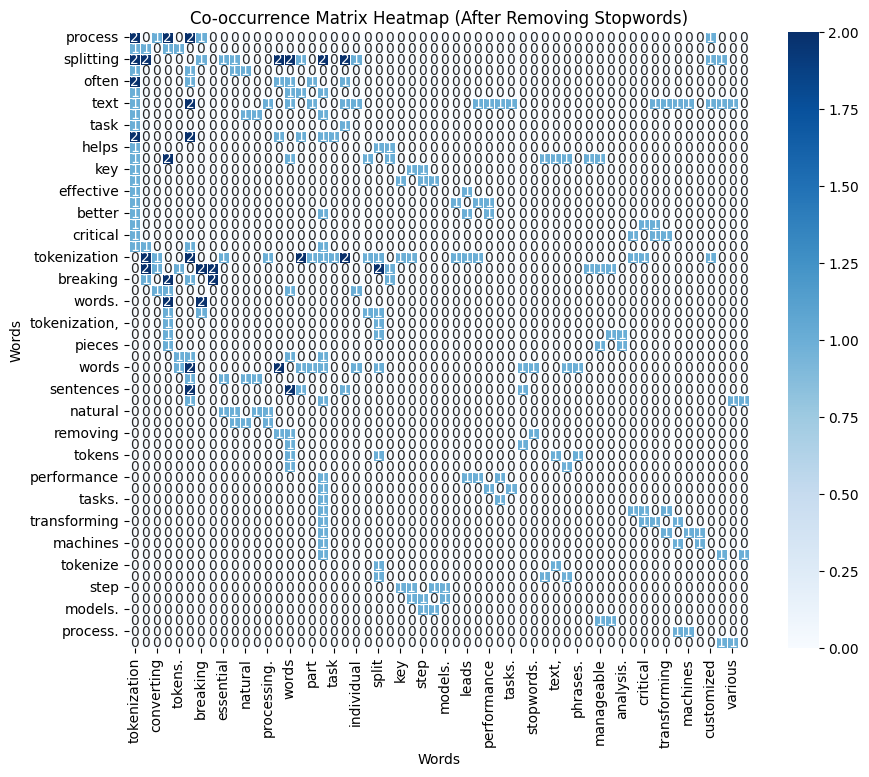

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from itertools import chain
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already available
nltk.download('stopwords')

# Initialize stopwords list
stop_words = set(stopwords.words('english'))

# Tokenize the sentences into words and convert to lowercase
tokenized_sentences = [
    [word.lower() for word in sentence.split() if word.lower() not in stop_words]
    for sentence in sentences
]

# Flatten the list of sentences into one vocabulary list
vocabulary = list(set(chain.from_iterable(tokenized_sentences)))

# Initialize co-occurrence dictionary
co_occurrence = defaultdict(lambda: defaultdict(int))

# Define context window size (number of words before/after the target word)
window_size = 2

# Build co-occurrence matrix
for sentence in tokenized_sentences:
    for i, word in enumerate(sentence):
        # Define the context window range
        start = max(0, i - window_size)
        end = min(len(sentence), i + window_size + 1)
        context_words = sentence[start:i] + sentence[i+1:end]  # Exclude the word itself

        # Update co-occurrence counts for the word
        for context_word in context_words:
            co_occurrence[word][context_word] += 1

# Convert the co-occurrence dictionary to a pandas DataFrame for visualization
co_occurrence_matrix = pd.DataFrame(co_occurrence).fillna(0)

# Convert float values to integer for better readability
co_occurrence_matrix = co_occurrence_matrix.astype(int)

# Plotting the co-occurrence matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, annot=True, cmap="Blues", fmt="d", linewidths=.5)
plt.title("Co-occurrence Matrix Heatmap (After Removing Stopwords)")
plt.xlabel("Words")
plt.ylabel("Words")
plt.xticks(rotation=90)
plt.show()

In [34]:
# Manually define a basic stopwords list
stop_words = {"is", "the", "and", "of", "a", "into", "we", "it", "in", "to", "by"}

# Tokenize the sentences into words and remove stopwords, convert to lowercase
tokenized_sentences = [
    [word.lower() for word in sentence.split() if word.lower() not in stop_words]
    for sentence in sentences
]

# Flatten the list of sentences into one vocabulary list
vocabulary = list(set(chain.from_iterable(tokenized_sentences)))

# Initialize co-occurrence dictionary
co_occurrence = defaultdict(lambda: defaultdict(int))

# Define context window size (number of words before/after the target word)
window_size = 2

# Build co-occurrence matrix
for sentence in tokenized_sentences:
    for i, word in enumerate(sentence):
        # Define the context window range
        start = max(0, i - window_size)
        end = min(len(sentence), i + window_size + 1)
        context_words = sentence[start:i] + sentence[i+1:end]  # Exclude the word itself

        # Update co-occurrence counts for the word
        for context_word in context_words:
            co_occurrence[word][context_word] += 1

# Convert the co-occurrence dictionary to a pandas DataFrame for visualization
co_occurrence_matrix = pd.DataFrame(co_occurrence).fillna(0)

# Convert float values to integer for better readability
co_occurrence_matrix = co_occurrence_matrix.astype(int)

# Display the co-occurrence matrix as a table
co_occurrence_matrix

,tokenization,process,converting,sentence,tokens.,splitting,breaking,words.,are,essential,...,that,machines,can,process.,be,customized,based,on,various,rules.
process,2,0,1,2,0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,0,0
converting,1,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
splitting,2,1,0,0,0,0,1,0,1,1,...,0,0,0,0,1,1,1,0,0,0
are,1,0,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
often,2,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
analysis.,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
machines,0,0,0,0,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,0
process.,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
various,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,1


# **Track 3.4: Semantic Similarit**y

In [35]:
import gensim
from gensim.models import Word2Vec
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Manually define a basic stopwords list
"""stop_words = {"is", "the", "and", "of", "a", "into", "we", "it", "in", "to", "by"}"""

# Download stopwords if not already available
nltk.download('stopwords')

# Initialize stopwords list
stop_words = set(stopwords.words('english'))

# Tokenize the sentences into words and remove stopwords, convert to lowercase
tokenized_sentences = [
    [word.lower() for word in sentence.split() if word.lower() not in stop_words]
    for sentence in sentences
]


# Train Word2Vec model on the tokenized sentences
model = Word2Vec(sentences=tokenized_sentences, vector_size=100, window=5, min_count=1, sg=1)

# Function to calculate cosine similarity between two words
def calculate_similarity(word1, word2):
    try:
        # Get the word vectors
        vec1 = model.wv[word1]
        vec2 = model.wv[word2]
        # Calculate cosine similarity
        similarity = cosine_similarity([vec1], [vec2])
        return similarity[0][0]
    except KeyError as e:
        return f"Word '{str(e)}' not in vocabulary."

# Calculate semantic similarity for a pair of words
similarity_tokenization_splitting = calculate_similarity('tokenization', 'splitting')
similarity_sentence_words = calculate_similarity('sentence', 'words')

print(f"Semantic Similarity between 'tokenization' and 'splitting': {similarity_tokenization_splitting}")
print(f"Semantic Similarity between 'sentence' and 'words': {similarity_sentence_words}")

# Now, let's create a similarity matrix for all words
vocabulary = list(model.wv.key_to_index.keys())
similarity_matrix = np.zeros((len(vocabulary), len(vocabulary)))

# Calculate pairwise similarity between all words
for i, word1 in enumerate(vocabulary):
    for j, word2 in enumerate(vocabulary):
        similarity_matrix[i][j] = calculate_similarity(word1, word2)

# Convert the similarity matrix to a pandas DataFrame for better readability
similarity_df = pd.DataFrame(similarity_matrix, index=vocabulary, columns=vocabulary)

# Display the similarity DataFrame
similarity_df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Semantic Similarity between 'tokenization' and 'splitting': -0.009737503714859486
Semantic Similarity between 'sentence' and 'words': -0.04432527348399162


,tokenization,splitting,text,words,sentence,split,process,involves,tokens.,often,...,preprocessing,key,models.,effective,leads,language,essential,steps,natural,converting
tokenization,1.000000,-0.009738,-0.051343,-0.110753,-0.027084,-0.058240,0.018661,0.094081,0.026942,0.215960,...,-0.069178,-0.089125,0.050468,0.038931,0.114112,-0.050196,0.123950,0.172013,0.086430,-0.049330
splitting,-0.009738,1.000000,-0.023028,0.067448,0.004901,0.009341,-0.112360,-0.114362,0.033411,-0.095668,...,0.055878,-0.170007,0.018076,-0.032745,-0.084688,0.184126,-0.016694,0.077505,-0.018600,0.052966
text,-0.051343,-0.023028,1.000000,-0.013325,0.170444,0.065434,0.146407,-0.002727,0.199017,-0.032920,...,0.040512,0.115309,0.073093,-0.110863,-0.035823,0.057622,0.201824,-0.138082,-0.071607,-0.034924
words,-0.110753,0.067448,-0.013325,1.000000,-0.044325,0.132561,0.041615,-0.013519,0.075124,-0.169321,...,-0.137063,-0.080756,-0.078413,0.097302,-0.075210,0.025148,-0.069385,-0.142765,-0.002544,-0.061444
sentence,-0.027084,0.004901,0.170444,-0.044325,1.000000,0.139037,0.035320,-0.028309,-0.068974,-0.173403,...,-0.076896,-0.076069,0.005365,0.017514,0.106542,-0.028581,0.054880,-0.239767,0.066572,0.060054
split,-0.058240,0.009341,0.065434,0.132561,0.139037,1.000000,0.019750,-0.057033,0.060741,-0.105129,...,0.032126,0.083490,-0.180281,0.067814,0.055298,-0.059428,-0.113047,-0.067468,0.106764,0.097112
process,0.018661,-0.112360,0.146407,0.041615,0.035320,0.019750,1.000000,0.006337,0.008464,0.002671,...,-0.177449,0.248175,-0.014937,0.058131,-0.005452,-0.041063,0.104844,-0.082373,-0.015676,0.002700
involves,0.094081,-0.114362,-0.002727,-0.013519,-0.028309,-0.057033,0.006337,1.000000,-0.144751,-0.092824,...,-0.011131,-0.033708,0.040785,0.044994,-0.018219,-0.008460,0.037385,0.050044,0.083080,0.178477
tokens.,0.026942,0.033411,0.199017,0.075124,-0.068974,0.060741,0.008464,-0.144751,1.000000,0.044448,...,0.032543,0.166815,0.172394,-0.104014,0.038755,-0.010578,0.239906,0.127201,-0.097312,0.022336
often,0.215960,-0.095668,-0.032920,-0.169321,-0.173403,-0.105129,0.002671,-0.092824,0.044448,1.000000,...,0.135072,0.060459,-0.008521,-0.153094,0.089799,-0.138440,-0.150767,0.247549,-0.014270,-0.086511
